# **Часть 1. Перенос стиля.**

Выбрали следующие датасеты с kaggle:

1.   Основа - черты лица людей (но используем их лишь в качестве портретов, черты здесь не будут важны)

2.   Стиль - Classic Art Style Comic Images (что-то мультяшное)



In [4]:
!pip install pycocotools

In [5]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


# **Загружаем наш (не наш) VGG19:**

In [6]:
import torch
from torchvision import models

vgg = models.vgg19(pretrained=True)
print(vgg)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:08<00:00, 64.9MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

**Используем встроенные опции настройки:**

In [7]:
vgg = vgg.features
print(vgg)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

In [8]:
for parameters in vgg.parameters():
  parameters.requires_grad_(False)

In [9]:
dev = torch.device("cuda" if torch.cuda.is_available else "cpu")
print(dev)

cuda


In [10]:
vgg.to(dev)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

# **Предобработка изображений:**

функция

In [11]:
from PIL import Image
from torchvision import transforms as T

def preprocess(img_path, max_size=500):
  image = Image.open(img_path).convert("RGB")
  if max(image.size) > max_size:
    size = max_size
  else:
    size = max(image.size)

  img_transforms = T.Compose([
      T.Resize(size),
      T.ToTensor(),
      T.Normalize(mean=[0.485, 0.456, 0.406],
                  std=[0.229, 0.224, 0.225])
  ])
  image = img_transforms(image)
  image = image.unsqueeze(0) # (3, 224, 224) -> (1, 3, 224, 224)

  return image

Перенос стиля просто на двух изображениях:

In [13]:
content_preprocess = preprocess('/content/gdrive/MyDrive/Colab Notebooks/datafaces/images/-florenceros_e_jpeg.rf.c89b43f320b612c48432ef2896d07df6.jpg')
style_preprocess = preprocess('/content/gdrive/MyDrive/Colab Notebooks/datastyle/classic/classic_img10.jpg')

content_preprocess = content_preprocess.to(dev)
style_preprocess = style_preprocess.to(dev)

print(f"Content shape {content_preprocess.shape}")
print(f"Style shape {style_preprocess.shape}")

Content shape torch.Size([1, 3, 500, 500])
Style shape torch.Size([1, 3, 301, 280])


**Вектор в картинку:**

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def deprocess(tensor):
  image = tensor.to("cpu").clone()
  image = image.numpy()
  image = image.squeeze(0) # (1, 3, 224, 224) -> (3, 224, 224)
  image = image.transpose(1, 2, 0) # (3, 224, 224) -> (224, 224, 3)
  image = image * np.array([0.485, 0.456, 0.406]) + np.array([0.229, 0.224, 0.225])
  image = image.clip(0,1)

  return image

In [15]:
content_deproc = deprocess(content_preprocess)
style_deproc = deprocess(style_preprocess)

print(f"Deprocess content: {content_deproc.shape}")
print(f"Deprocess style: {style_deproc.shape}")

Deprocess content: (500, 500, 3)
Deprocess style: (301, 280, 3)


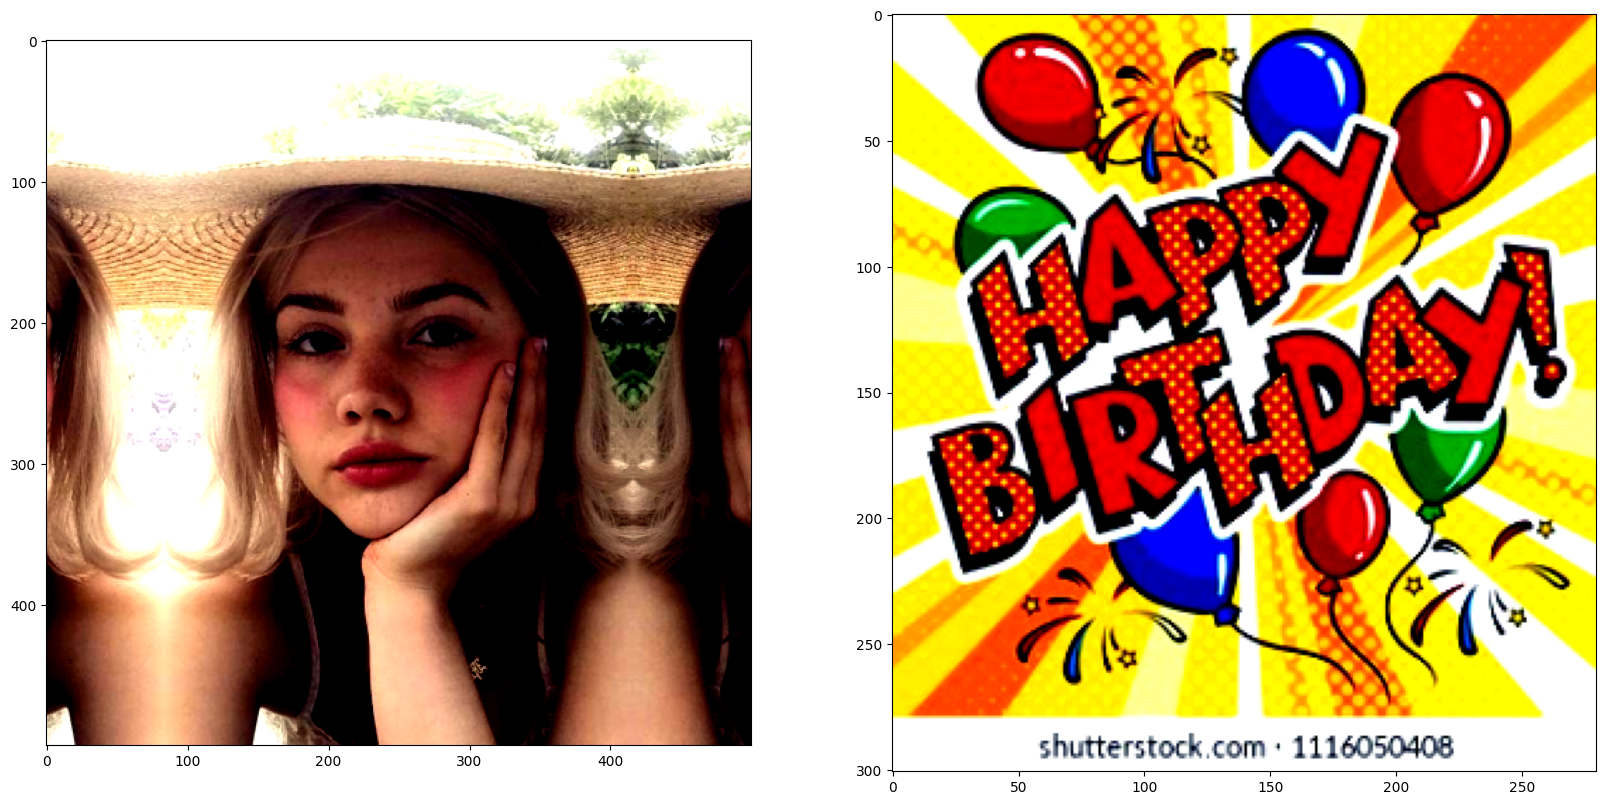

In [16]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(20,10))
ax1.imshow(content_deproc)
ax2.imshow(style_deproc);

**Извлечение признаков из изображений, матрица Грама:**

In [17]:
def get_features(image, model):
  layers = {
      "0": "conv1_1",  # see representaion.png
      "5": "conv2_1",
      "10": "conv3_1",
      "19": "conv4_1",
      "21": "conv4_2", #content_feature
      "28": "conv5_1"
  }

  x = image
  Features = {}
  for name, layer in model._modules.items():
    x = layer(x)
    if name in layers:
      Features[layers[name]] = x

  return Features

In [18]:
content_features = get_features(content_preprocess, vgg)
style_features = get_features(style_preprocess, vgg)

In [19]:
def gram_matrix(tensor):
  b, c, h, w = tensor.size()
  tensor = tensor.view(c, h*w)
  gram = torch.mm(tensor, tensor.t())
  return gram

In [20]:
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

# **Создание функций потерь для изображения и стиля:**

In [21]:
def content_loss(target_conv4_2, content_conv4_2):
  loss = torch.mean((target_conv4_2-content_conv4_2)**2)
  return loss

In [22]:
style_weights = {
    "conv1_1": 1.0,
    "conv2_1": 0.75,
    "conv3_1": 0.75,
    "conv4_1": 0.75,
    "conv5_1": 0.75
}

In [23]:
def style_loss(style_weights, target_fs, style_grams):
  loss = 0
  for layer in style_weights:
    target_feature = target_fs[layer]
    target_gram = gram_matrix(target_feature)
    style_gram = style_grams[layer]
    b, c, h, w = target_feature.shape
    layer_loss = style_weights[layer]*torch.mean((target_gram-style_gram)**2)
    loss += layer_loss/(c*h*w)

  return loss

In [24]:
target = content_preprocess.clone().requires_grad_(True).to(dev)
target_f = get_features(target,vgg)
print(f"Content loss: {content_loss(target_f['conv4_2'], content_features['conv4_2'])}")
print(f"Style loss: {style_loss(style_weights, target_f,style_grams)}")

Content loss: 0.0
Style loss: 1022.6383056640625


# **Обучение модели.**

In [26]:
from torch import optim

optimizer = optim.Adam([target],lr=0.003)

alpha = 1.0
beta = 1e5
epochs = 4000
show_every = 500

NameError: name 'target' is not defined

In [26]:
def total_loss(c_loss, s_loss, alpha, beta):
  loss = alpha*c_loss + beta*s_loss
  return loss

In [27]:
results = []

for i in range(epochs):
  target_f = get_features(target,vgg)
  c_loss = content_loss(target_f["conv4_2"], content_features["conv4_2"])
  s_loss = style_loss(style_weights, target_f, style_grams)
  t_loss = total_loss(c_loss,s_loss, alpha, beta)

  optimizer.zero_grad()
  t_loss.backward()
  optimizer.step()

  if i % show_every == 0:
    print(f"Total loss at Epoch {i}: {t_loss}")
    results.append(deprocess(target.detach()))

Total loss at Epoch 0: 102263832.0
Total loss at Epoch 500: 7634515.5
Total loss at Epoch 1000: 4530252.5
Total loss at Epoch 1500: 3268754.25
Total loss at Epoch 2000: 2641656.25
Total loss at Epoch 2500: 2270451.25
Total loss at Epoch 3000: 2003214.625
Total loss at Epoch 3500: 1776997.5


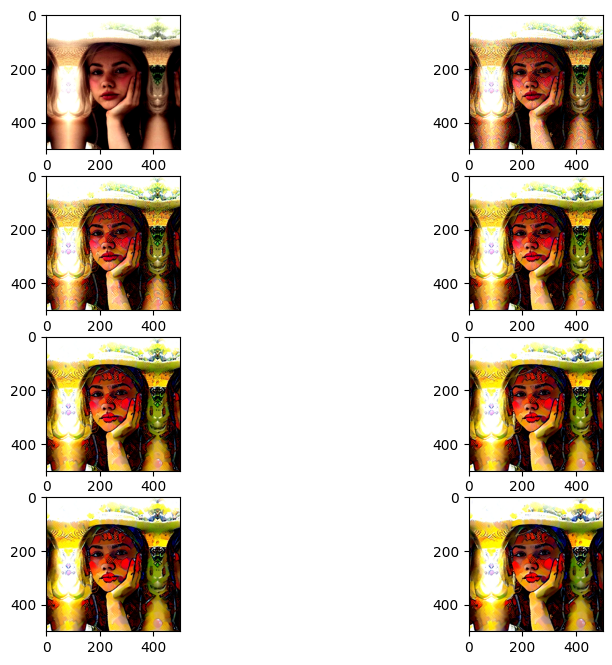

In [28]:
plt.figure(figsize=(10,8))
for i,_ in enumerate(results):
  plt.subplot(4,2, i+1)
  plt.imshow(results[i])
plt.show()

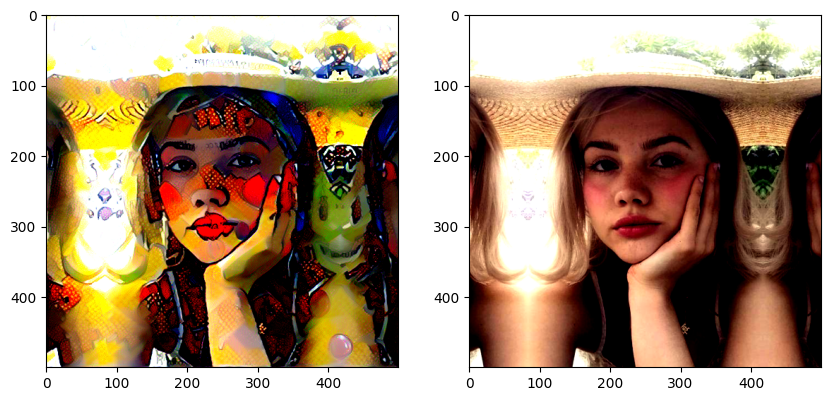

In [29]:
target_copy = deprocess(target.detach())
content_copy = deprocess(content_preprocess)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
ax1.imshow(target_copy)
ax2.imshow(content_copy);

Уже выглядит неплохо, губы вообще здорово разукрасились для одной генерации!

Нам тут подсказали, что нескольких примеров будет достаточно, поэтому в коде ниже мы указываем для использования следующее количество:

3 картинки основ

10 картинок стиля

In [1]:
from torch import optim
import os

In [32]:
style_dir = '/content/gdrive/MyDrive/Colab Notebooks/datastyle/classic'
content_dir = '/content/gdrive/MyDrive/Colab Notebooks/datafaces/images'
output_dir = '/content/gdrive/MyDrive/Colab Notebooks/res'  # Папка для сохранения результата

os.makedirs(output_dir, exist_ok=True)

content_images = sorted(os.listdir(content_dir))[:3]
style_images = sorted(os.listdir(style_dir))[:10]

for content_img, style_img in zip(content_images, style_images):
    content_path = os.path.join(content_dir, content_img)
    style_path = os.path.join(style_dir, style_img)

    content_preprocess = preprocess(content_path).to(dev)
    style_preprocess = preprocess(style_path).to(dev)

    content_features = get_features(content_preprocess, vgg)
    style_features = get_features(style_preprocess, vgg)
    style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

    target = content_preprocess.clone().requires_grad_(True).to(dev)
    optimizer = optim.Adam([target], lr=0.003)

    for i in range(epochs):
        target_features = get_features(target, vgg)
        c_loss = content_loss(target_features["conv4_2"], content_features["conv4_2"])
        s_loss = style_loss(style_weights, target_features, style_grams)
        t_loss = total_loss(c_loss, s_loss, alpha, beta)

        optimizer.zero_grad()
        t_loss.backward()
        optimizer.step()

    output_image = deprocess(target.detach())
    output_image = Image.fromarray((output_image * 255).astype("uint8"))
    output_image.save(os.path.join(output_dir, f"stylized_{content_img}"))
    print(f"Saved stylized image for {content_img}")

Saved stylized image for -28_49-ssstein-2020-21-_jpeg.rf.13a5a8148671bf29e8ccf749cf2fc7a3.jpg
Saved stylized image for -__________k_j______jpeg.rf.84db32bf2b50291a5f8c95b8fe98819a.jpg
Saved stylized image for -_jpeg.rf.36c1daee213eece325b050f06ca42c7a.jpg


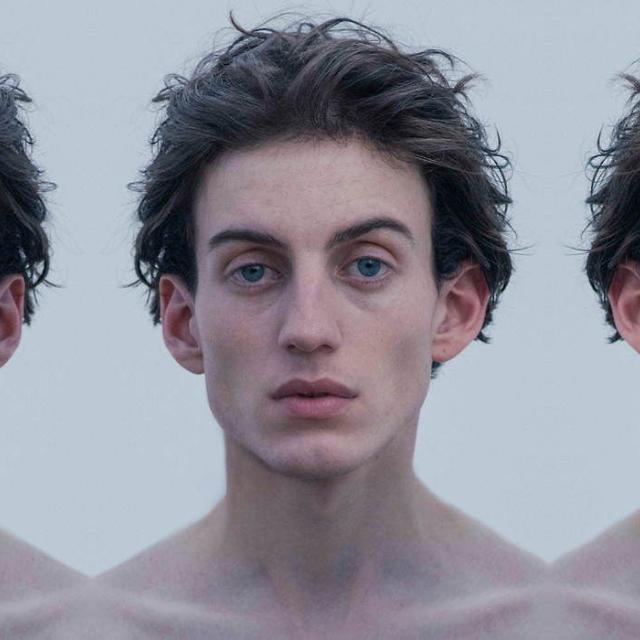 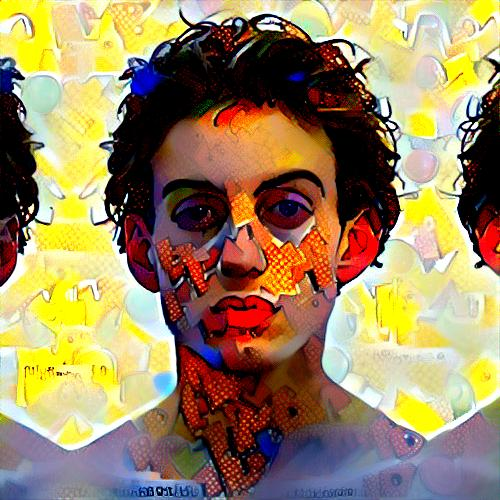

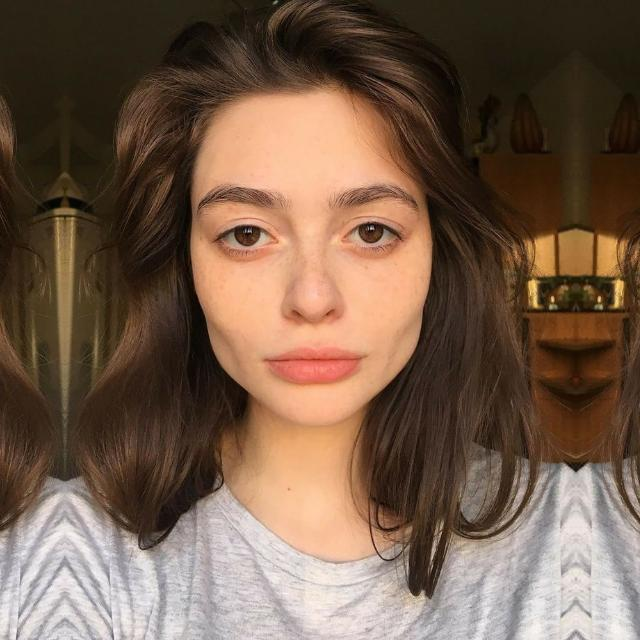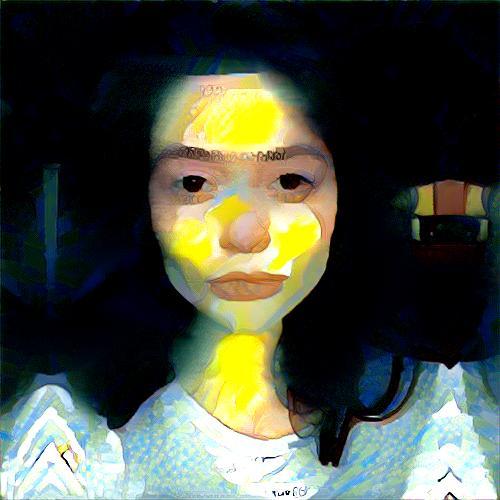

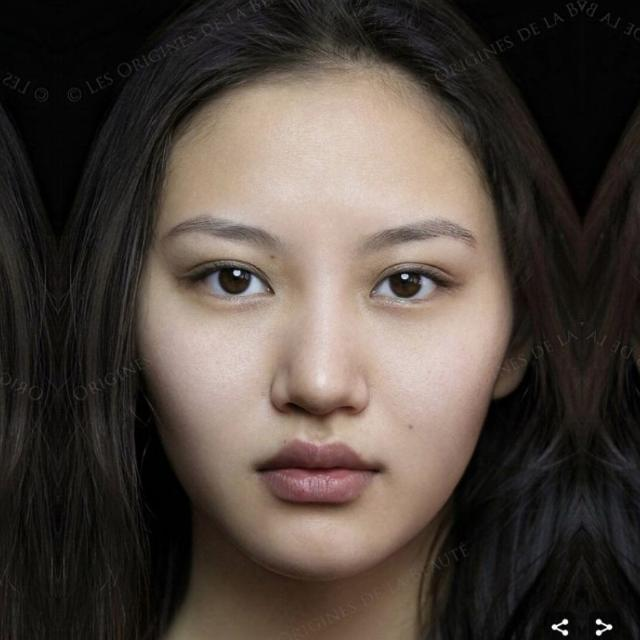 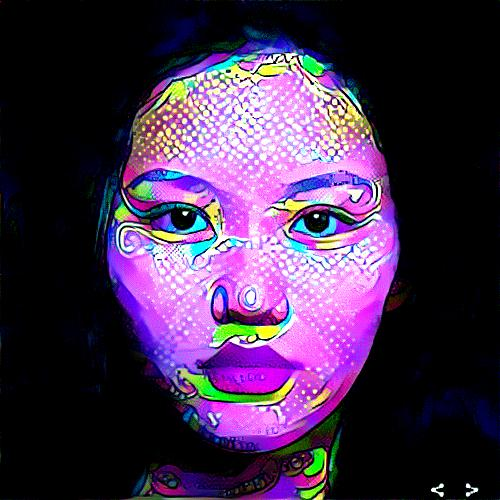

** Компилилось это почти 20 минут! **

**Вот такие вот забавные итоги. Вроде всё удалось, эта часть лабы нам очень сильно понравилась и показалась полезной. Спасибо, что познакомили с VGG19!**

# **# Часть 2. Классификация**

**На основе данных EMNIST - рукописные английские буквы в двух регистрах**

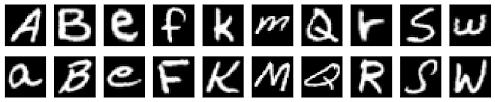

**Загрузка и аугментация данных**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

batch_size = 64
num_classes = 47  # В EMNIST 47 классов (буквы и цифры)
learning_rate = 0.001
epochs = 10

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # убеждаемся, что 1-канальное изображение
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = datasets.EMNIST(root="./data", split="letters", train=True, download=True, transform=transform)
testset = datasets.EMNIST(root="./data", split="letters", train=False, download=True, transform=transform)

# создание того самого даталоадера
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)


100%|██████████| 562M/562M [00:31<00:00, 17.8MB/s]


Extracting ./data/EMNIST/raw/gzip.zip to ./data/EMNIST/raw


**Создание нейросети!**

Не получилось с лекционной поработать нормально, почему-то памяти не хватало прям слишком сильно, пришлось переделывать эту часть лабы с нуля.

In [2]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(num_classes).to(device)


**Оптимизатор и функция потерь:**

In [3]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


**Цикл обучения:**

In [4]:
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(trainloader):.4f}")


Epoch [1/10], Loss: 0.4715
Epoch [2/10], Loss: 0.2381
Epoch [3/10], Loss: 0.1939
Epoch [4/10], Loss: 0.1682
Epoch [5/10], Loss: 0.1483
Epoch [6/10], Loss: 0.1338
Epoch [7/10], Loss: 0.1196
Epoch [8/10], Loss: 0.1083
Epoch [9/10], Loss: 0.0998
Epoch [10/10], Loss: 0.0922


Не стали смотреть на результат после каждой итерации, а дождались сразу 10 эпох.

Но даже так видно, что Loss с каждым разом уменьшается в разы медленее, чем изначально. Ну экспоненциальная зависимость, насколько помним математику)

**Проверка точности на тест-наборе данных:**

In [5]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Точность на тестовых данных: {accuracy:.2f}%")


Точность на тестовых данных: 93.17%


Ваууу! Точность оказалась больше 90%, это значит, что цель выполнена и можно спокойно засыпать.. утром..

Спасибо огромное за курс, один из нас выберет модуль аналитики в дальнейшем и будет Вам еще больше благодарен за два проведенных курса и классную систему обучения)

In [ ]:
# Веселых каникул! ;-)